dataset: https://www.geeksforgeeks.org/machine-learning/dataset-for-linear-regression/

In [1]:
# Basic libraries for data handling and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load the Boston dataset
df = pd.read_csv("/content/diabetes[1] (1).csv")

# Show first 5 rows
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Number of rows and columns
print(df.shape)

# Column names
print(df.columns)

# Basic statistics
print(df.describe())

(768, 9)
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean 

<Axes: >

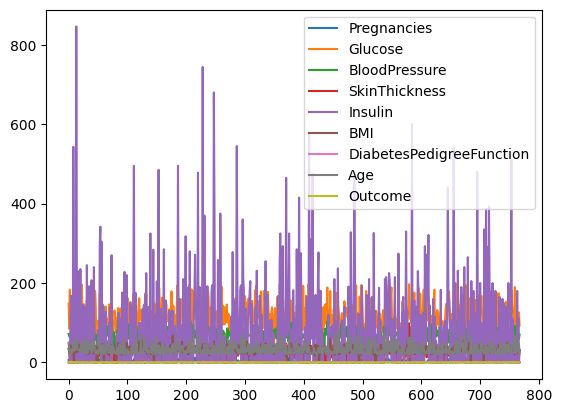

In [4]:
df.plot()

In [5]:
# Check if any column has missing values
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [6]:
df.shape

(768, 9)

In [7]:
# Target variable (what we want to predict)
y = df['Outcome']   # median house price

# Features (everything else)
X = df.drop('Outcome', axis=1)

In [8]:
# 80% training, 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [9]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(614, 8)
(154, 8)
(614,)
(154,)


In [10]:
# Create model
model = LinearRegression()

# Train model using training data
model.fit(X_train, y_train)

LinearRegression()

In [11]:
# Predict on test data
y_pred = model.predict(X_test)

# Show first 5 predictions
print(y_pred[:5])

[0.33550028 0.23809869 0.1510522  0.2401365  0.48142376]


In [12]:
print(y_test[:5])

668    0
324    0
624    0
690    0
473    0
Name: Outcome, dtype: int64


In [13]:
# Mean Squared Error (lower is better)
mse = mean_squared_error(y_test, y_pred)

# R2 Score (closer to 1 is better)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 0.17104527280850104
R2 Score: 0.25500281176741757


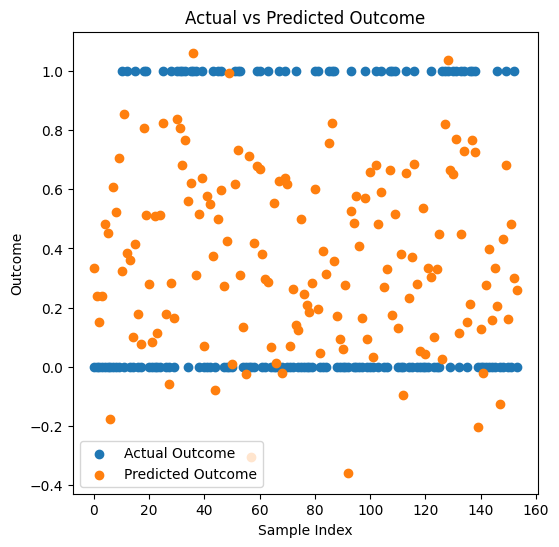

In [15]:
# Plot Actual vs Predicted values using two different colors

plt.figure(figsize=(6,6))

# Actual values (blue)
plt.scatter(range(len(y_test)), y_test, label="Actual Outcome")

# Predicted values (orange)
plt.scatter(range(len(y_pred)), y_pred, label="Predicted Outcome")

plt.xlabel("Sample Index")
plt.ylabel("Outcome")
plt.title("Actual vs Predicted Outcome")

# Show legend so colors are explained
plt.legend()

plt.show()

What if we use classification??
use logistic regression??

In [17]:
from sklearn.preprocessing import StandardScaler #scaling the data

In [18]:
# Scaling makes all features comparable in size

scaler = StandardScaler()

# Fit on training data ONLY
X_train_scaled = scaler.fit_transform(X_train)

# Use same scaler on test data
X_test_scaled = scaler.transform(X_test)

In [20]:
from sklearn.linear_model import LogisticRegression #importing the ML model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix #importing all the metrics


In [21]:
# Create model
lr = LogisticRegression()

# Train model
lr.fit(X_train_scaled, y_train)

LogisticRegression()

In [22]:
# Predict on test data
y_pred = lr.predict(X_test_scaled)



In [23]:
print(y_pred[:5])

[0 0 0 0 0]


In [24]:
print(y_test[:5])

668    0
324    0
624    0
690    0
473    0
Name: Outcome, dtype: int64


In [25]:
# Detailed report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



In [26]:
print(confusion_matrix(y_test, y_pred)) #confusion matrix

[[79 20]
 [18 37]]


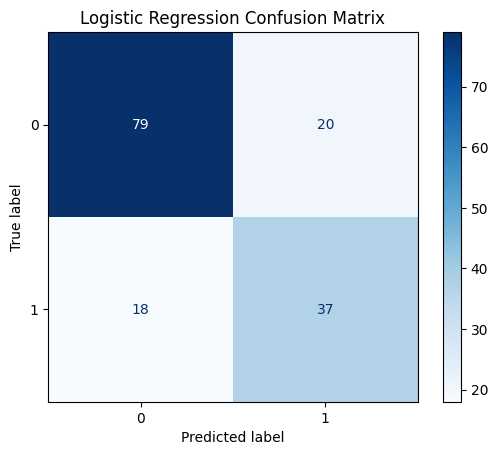

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Display colored confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.show()